<a href="https://colab.research.google.com/github/PedroHNeves1505/CP2-SERS-Semestre-2/blob/main/AULA_07_Regress%C3%A3o_Linear_com_Dados_de_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [2]:
# Importe aqui as bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [3]:
# Carregue o dataset e realize a análise inicial

dados = pd.read_csv('https://raw.githubusercontent.com/PedroHNeves1505/CP2-SERS-Semestre-2/refs/heads/main/Raw_Data.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Registro da análise inicial

**Quantidade de linhas:**  
**Quantidade de colunas:**  
**Existem valores ausentes?**  
**Observações importantes sobre o dataset:**  

## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [5]:
# Crie a variável y usando a coluna stab
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

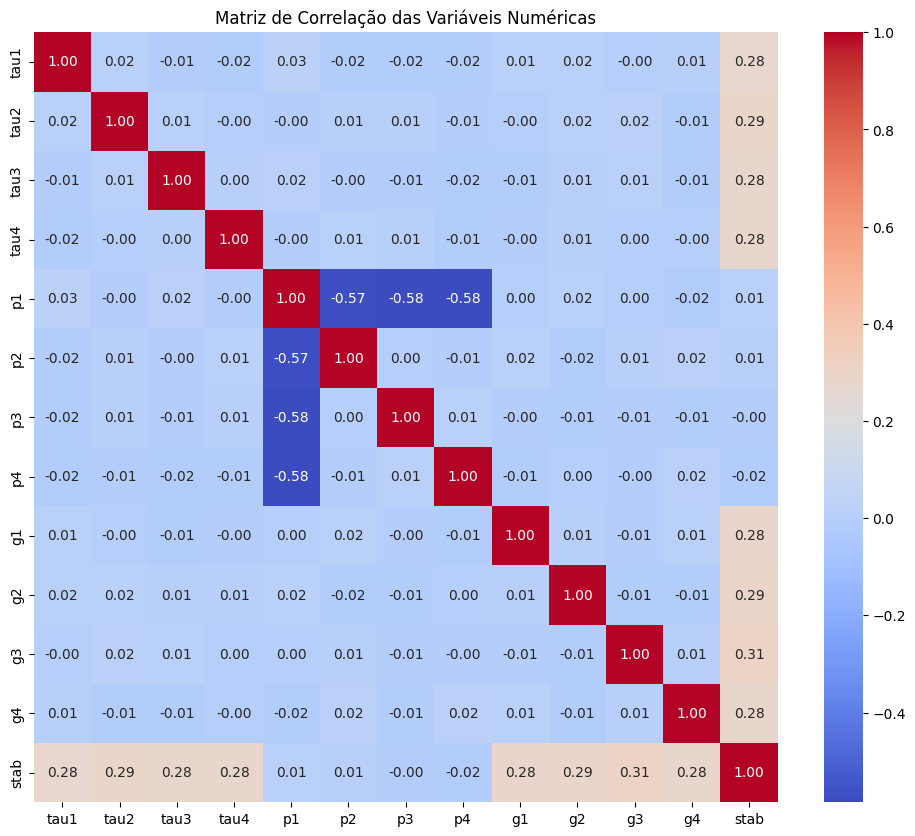


Five variables with the highest absolute correlation with 'stab':
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
Name: stab, dtype: float64

List of top 5 correlated variables: ['g3', 'g2', 'tau2', 'g1', 'tau3']


In [13]:
# Calcule e visualize a matriz de correlação

corr_matrix = dados.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

correlations_with_stab = dados.corr(numeric_only=True)['stab'].drop('stab')
top_5_correlated = correlations_with_stab.abs().sort_values(ascending=False).head(5)

print("\nFive variables with the highest absolute correlation with 'stab':")
print(correlations_with_stab[top_5_correlated.index])

cinco_variaveis = top_5_correlated.index.tolist()
print(f"\nList of top 5 correlated variables: {cinco_variaveis}")

## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

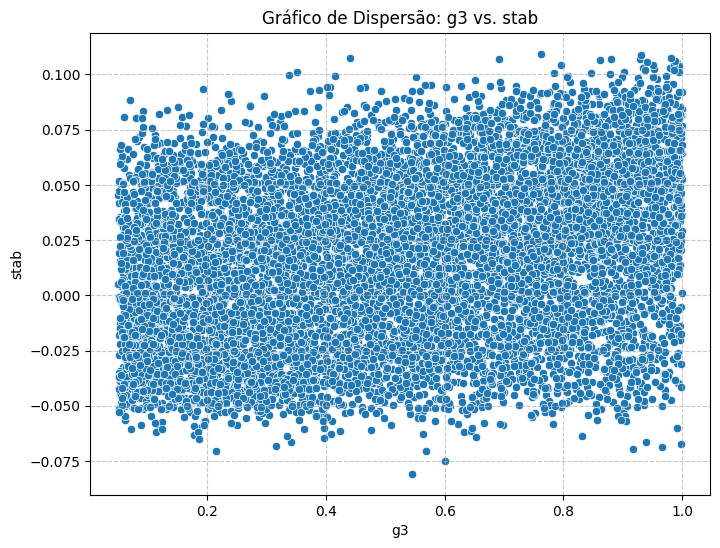

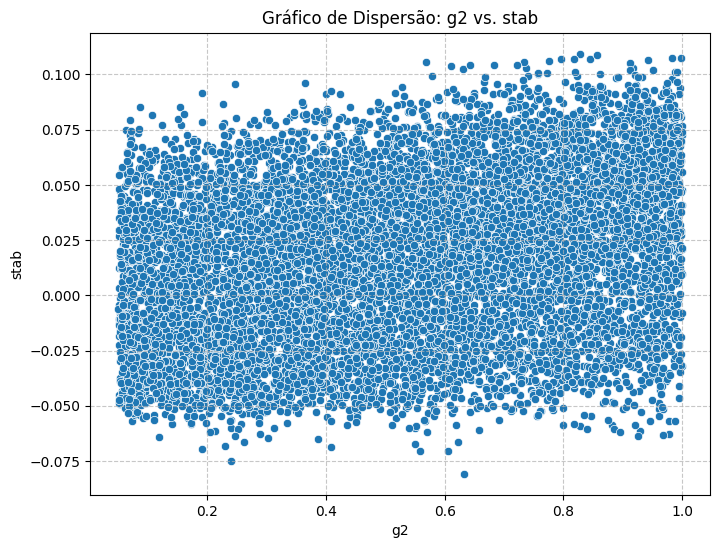

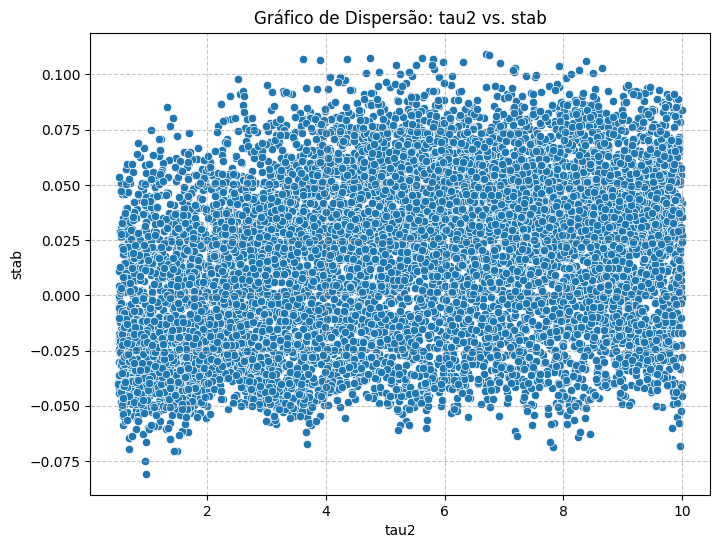

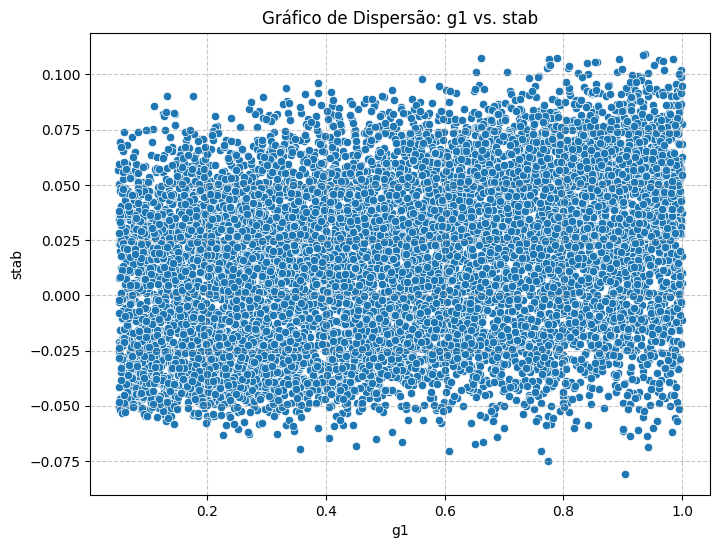

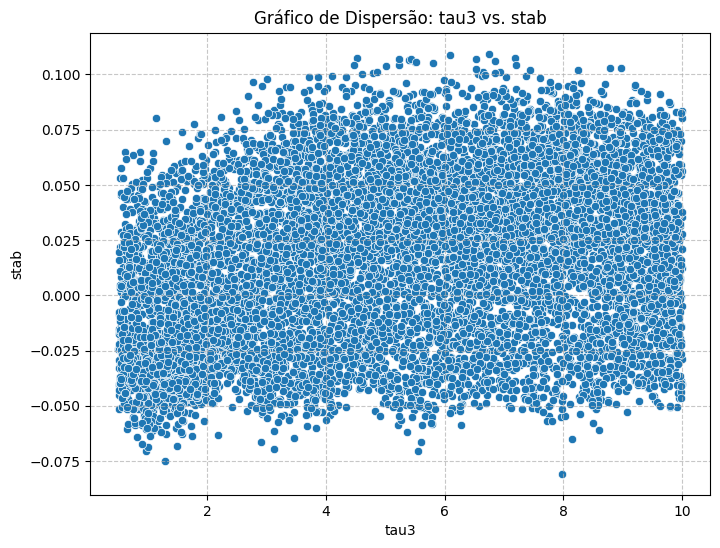

In [16]:
# Cole, revise e execute aqui o código gerado com o apoio do Gemini

for var in cinco_variaveis:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=dados[var], y=dados['stab'])
    plt.title(f'Gráfico de Dispersão: {var} vs. stab')
    plt.xlabel(var)
    plt.ylabel('stab')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|----:|---------:|
| 1 | g3   | 0.308235 |
| 2 | g2   | 0.293601 |
| 3 | tau2 | 0.290975 |
| 4 | g1   | 0.282774 |
| 5 | tau3 | 0.280700 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: A variável que apresentou maior correlação com a 'stab' foi a g3

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Eles indicam que não há uma correlação linear forte ou evidente já que os pontos do gráfico estão muito espalahados no plano, quase cobrindo todo os pontos do gráfico

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [25]:
# Crie X com as cinco variáveis selecionadas

X = dados[cinco_variaveis]

# Mostre as primeiras linhas de X e y

print(f'5 Primeiras linhas do X: \n{X.head()}')
print(f'\n{'=' * 60} \n')
print(f'5 Primeiras linhas do y: \n{y.head()}')

5 Primeiras linhas do X: 
         g3        g2      tau2        g1      tau3
0  0.887445  0.859578  3.079885  0.650456  8.381025
1  0.562139  0.862414  4.902524  0.413441  3.047541
2  0.839444  0.766689  8.848428  0.163041  3.046479
3  0.929381  0.976744  7.669600  0.446209  4.486641
4  0.656947  0.455450  7.608772  0.797110  4.943759


5 Primeiras linhas do y: 
0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [26]:
# Separe os dados de treino e teste do Modelo 1

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [27]:
# Crie e treine modeloLR

modeloLR = LinearRegression()
modeloLR.fit(x_treino, y_treino)

# Gere y_previsao_1

y_previsao_1 = modeloLR.predict(x_teste)

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [30]:
# Calcule e apresente as três métricas do Modelo 1

r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f'R² do Modelo 1: {r2_modelo_1}')
print(f'MAE do Modelo 1: {mae_modelo_1}')
print(f'MSE do Modelo 1: {mse_modelo_1}')

R² do Modelo 1: 0.40176964852172137
MAE do Modelo 1: 0.023309678710004788
MSE do Modelo 1: 0.000811420863922188


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [31]:
# Selecione todas as colunas iniciadas por tau ou g
X_tau_g = dados.filter(regex='^(tau|g)')

# Liste as colunas selecionadas

print(X_tau_g.columns)

Index(['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4'], dtype='object')


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [32]:
# Separe os dados de treino e teste do Modelo 2

x2_treino, x2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)

# Confirme se y_teste e y2_teste possuem os mesmos índices

print(y_teste.equals(y2_teste))

True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [35]:
# Crie e treine modeloLR_tau_g

modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(x2_treino, y2_treino)

# Gere y_previsao_2

y_previsao_2 = modeloLR_tau_g.predict(x2_teste)

# Calcule e apresente as três métricas do Modelo 2

R2_modelo_2 = r2_score(y2_teste, y_previsao_2)
MAE_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
MSE_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f'R² do Modelo 2: {R2_modelo_2}')
print(f'MAE do Modelo 2: {MAE_modelo_2}')
print(f'MSE do Modelo 2: {MSE_modelo_2}')


R² do Modelo 2: 0.6452288156705858
MAE do Modelo 2: 0.01755303887582674
MSE do Modelo 2: 0.00048120049437799794


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [39]:
# Crie e exiba o DataFrame comparacao_modelos

comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['Cinco variáveis', 'Todas as variáveis tau e g'],
    'R²': [r2_modelo_1, R2_modelo_2],
    'MAE': [mae_modelo_1, MAE_modelo_2],
    'MSE': [mse_modelo_1, MSE_modelo_2]
})

comparacao_modelos.head()

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,Cinco variáveis,0.401770,0.023310,0.000811
1,Modelo 2,Todas as variáveis tau e g,0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

Text(0, 0.5, 'MSE')

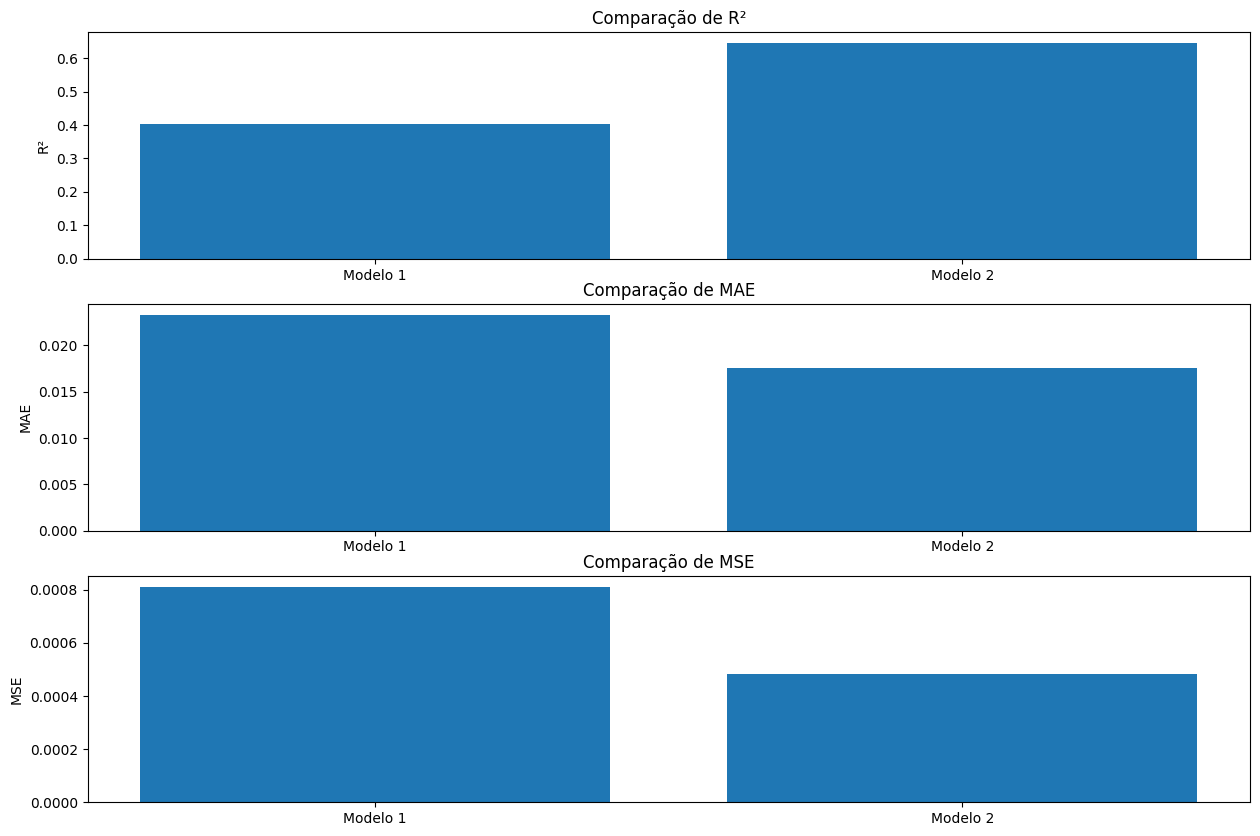

In [44]:
# Crie os gráficos comparativos das métricas

plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['R²'])
plt.title('Comparação de R²')
plt.ylabel('R²')

plt.subplot(3, 1, 2)
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['MAE'])
plt.title('Comparação de MAE')
plt.ylabel('MAE')

plt.subplot(3, 1, 3)
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['MSE'])
plt.title('Comparação de MSE')
plt.ylabel('MSE')


## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: Modelo 2(Todas as variáveis tau e g) apresentou um R² maior com 0.645229 enquanto o Modelo 1(Cinco variáveis) teve 0.401770
**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: Modelo 2(Todas as variáveis tau e g) apresentou um MAE menor com 0.017553 enquanto o Modelo 1(Cinco variáveis) teve 0.023310  

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: Modelo 2(Todas as variáveis tau e g) apresentou um MSE menor com 0.000481 enquanto o Modelo 1(Cinco variáveis) teve 0.000811  

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim, as 3 métricas indicaram o Modelo 2(Todas as variáveis tau e g) como o de melhor desempenho, já que como visto nas questões acima ela apresentou uma maior R² e menores MAE e MSE.
**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: O desempenho melhorou significativamente. O Modelo 2(Todas as variáveis tau e g) apresentou uma capacidade muito maior de explicar a variação dos dados (R² maior) e reduziu os erros nas previsões (MAE e MSE menores) em comparação ao Modelo 1(Cinco variáveis).

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Escolheria o Modelo 2 (Todas as variáveis tau e g) para prever a variável stab, pois ele apresentou um desempenho superior em todas as métricas avaliadas. O modelo demonstrou maior capacidade explicativa ao atingir um R² de 0.645229, superando o valor de 0.401770 do primeiro modelo. Além disso, o Modelo 2 apresentou previsões mais precisas e com menor margem de erro, registrando um MAE menor (0.017553 frente a 0.023310) e um MSE expressivamente menor (0.000481 frente a 0.000811), o que confirma sua maior confiabilidade para a tarefa.  

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.